# Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and Clean Data

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/Projects/01_NDVI_Classification_Stability/data/raw/NDVI_Grid_Comparison.csv")

# Keep only necessary columns
df = df[['Grid_ID', 'NDVI_A', 'NDVI_B', 'NDVI_C']]

# Remove missing values
df = df.dropna()

# Explore the Data

In [ ]:
print(df[['NDVI_A','NDVI_B','NDVI_C']].describe())

             NDVI_A        NDVI_B        NDVI_C
count  87982.000000  87982.000000  87982.000000
mean       0.528560      0.538647      0.507161
std        0.264323      0.268551      0.255821
min       -0.737933     -0.761386     -0.739037
25%        0.445319      0.463808      0.417232
50%        0.613096      0.629722      0.578856
75%        0.703791      0.713077      0.681548
max        0.926695      0.927831      0.915133


# Compare Pipeline Numerically

In [ ]:
df["Diff_AB"] = df["NDVI_A"] - df["NDVI_B"]
df["Diff_AC"] = df["NDVI_A"] - df["NDVI_C"]
df["Diff_BC"] = df["NDVI_B"] - df["NDVI_C"]

Difference can be negative or posetive thats why we need first convert to absulute value

In [ ]:
print(df[['Diff_AB','Diff_AC','Diff_BC']].abs().mean())

Diff_AB    0.013941
Diff_AC    0.026916
Diff_BC    0.038493
dtype: float64


# General Classifier function

In [ ]:
def classify(ndvi, low, high):
    if ndvi < low:
        return "Low"
    elif ndvi < high:
        return "Moderate"
    else:
        return "High"

## Threshold system 1 (0.30 / 0.50)

In [ ]:
df["Class_A_T1"] = df["NDVI_A"].apply(lambda x: classify(x, 0.30, 0.50))
df["Class_B_T1"] = df["NDVI_B"].apply(lambda x: classify(x, 0.30, 0.50))
df["Class_C_T1"] = df["NDVI_C"].apply(lambda x: classify(x, 0.30, 0.50))

## Threshold system 2 (0.35 / 0.55)

In [ ]:
df["Class_A_T2"] = df["NDVI_A"].apply(lambda x: classify(x, 0.35, 0.55))
df["Class_B_T2"] = df["NDVI_B"].apply(lambda x: classify(x, 0.35, 0.55))
df["Class_C_T2"] = df["NDVI_C"].apply(lambda x: classify(x, 0.35, 0.55))

## Threshold system 3 (0.40 / 0.60)

In [ ]:
df["Class_A_T3"] = df["NDVI_A"].apply(lambda x: classify(x, 0.40, 0.60))
df["Class_B_T3"] = df["NDVI_B"].apply(lambda x: classify(x, 0.40, 0.60))
df["Class_C_T3"] = df["NDVI_C"].apply(lambda x: classify(x, 0.40, 0.60))

# Check Class distribution

In [ ]:
print(df["Class_A_T1"].value_counts())
print(df["Class_B_T1"].value_counts())
print(df["Class_C_T1"].value_counts())

Class_A_T1
High        61053
Low         13693
Moderate    13236
Name: count, dtype: int64
Class_B_T1
High        62963
Low         13270
Moderate    11749
Name: count, dtype: int64
Class_C_T1
High        56906
Moderate    16516
Low         14560
Name: count, dtype: int64


# DECISION FLIP ANALYSIS

In [ ]:
df["Flip_AB"] = (df["Class_A_T1"] != df["Class_B_T1"]).astype(int)
df["Flip_AC"] = (df["Class_A_T1"] != df["Class_C_T1"]).astype(int)
df["Flip_BC"] = (df["Class_B_T1"] != df["Class_C_T1"]).astype(int)

## Compute flip rate

In [ ]:
flip_ab = df["Flip_AB"].mean()
flip_ac = df["Flip_AC"].mean()
flip_bc = df["Flip_BC"].mean()

In [ ]:
flip_rates = {
    "A vs B": df["Flip_AB"].mean() * 100,
    "A vs C": df["Flip_AC"].mean() * 100,
    "B vs C": df["Flip_BC"].mean() * 100
}

print(flip_rates)

{'A vs B': np.float64(3.1460980655134003), 'A vs C': np.float64(6.066013502761929), 'B vs C': np.float64(8.698370121161146)}


In [ ]:
# Convert to dataframe
import pandas as pd

flip_df = pd.DataFrame({
    "Comparison": list(flip_rates.keys()),
    "Flip Rate": list(flip_rates.values())
})

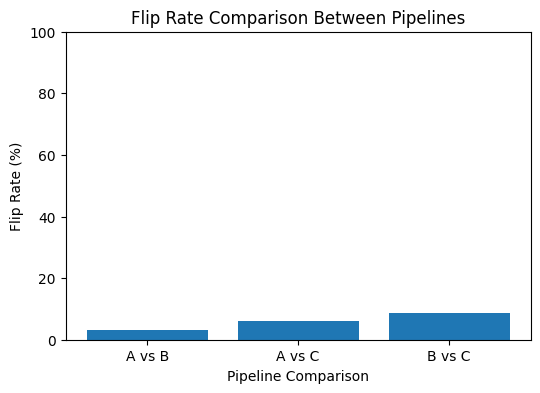

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(flip_df["Comparison"], flip_df["Flip Rate"])

plt.title("Flip Rate Comparison Between Pipelines")
plt.ylabel("Flip Rate (%)")
plt.xlabel("Pipeline Comparison")

plt.ylim(0, 100)

plt.show()

# Confusion matrix

In [ ]:
labels = ["Low", "Moderate", "High"]

In [ ]:
from sklearn.metrics import confusion_matrix

cm_AB = confusion_matrix(df["Class_A_T1"], df["Class_B_T1"],labels=labels)
cm_AC = confusion_matrix(df["Class_A_T1"], df["Class_C_T1"],labels=labels)
cm_BC = confusion_matrix(df["Class_B_T1"], df["Class_C_T1"],labels=labels)

In [ ]:
cm_df_AB = pd.DataFrame(cm_AB, index=labels, columns=labels)
cm_df_AC = pd.DataFrame(cm_AC, index=labels, columns=labels)
cm_df_BC = pd.DataFrame(cm_BC, index=labels, columns=labels)

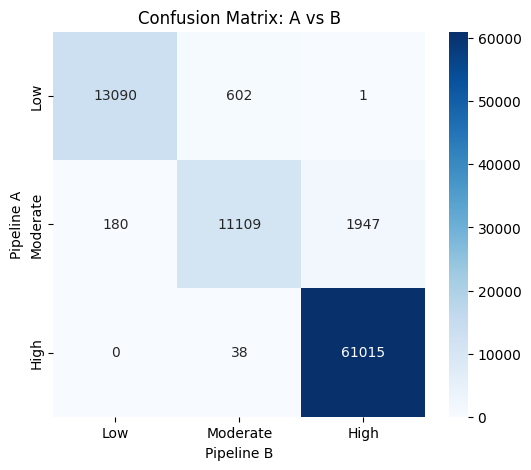

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_df_AB,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix: A vs B")
plt.xlabel("Pipeline B")
plt.ylabel("Pipeline A")
plt.show()

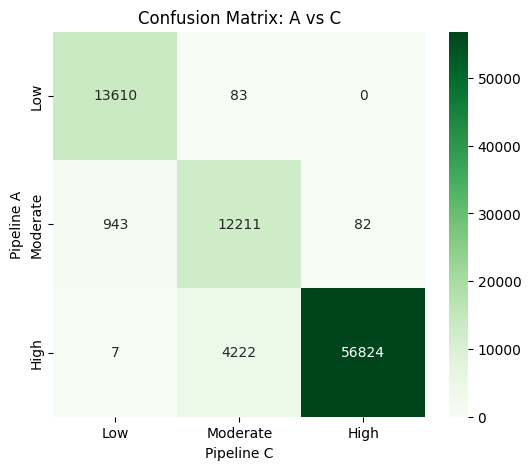

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_df_AC, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix: A vs C")
plt.xlabel("Pipeline C")
plt.ylabel("Pipeline A")
plt.show()

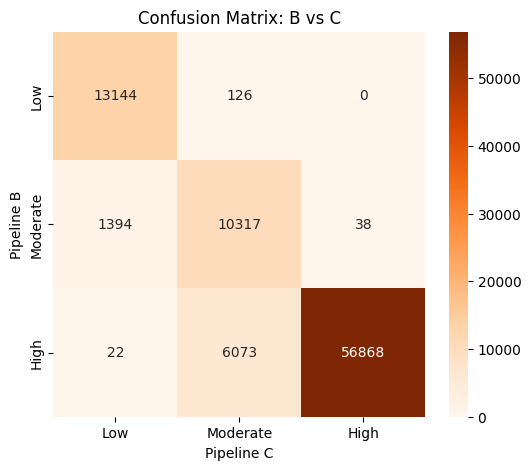

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_df_BC, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix: B vs C")
plt.xlabel("Pipeline C")
plt.ylabel("Pipeline B")
plt.show()

In [ ]:
df = df[['Grid_ID', 'NDVI_A', 'NDVI_B', 'NDVI_C', 'Class_A_T1','Class_B_T1','Class_C_T1','Flip_AB','Flip_AC','Flip_BC']]

In [ ]:
df.to_csv("final_analysis_table.csv", index=False)

# Histogram creation

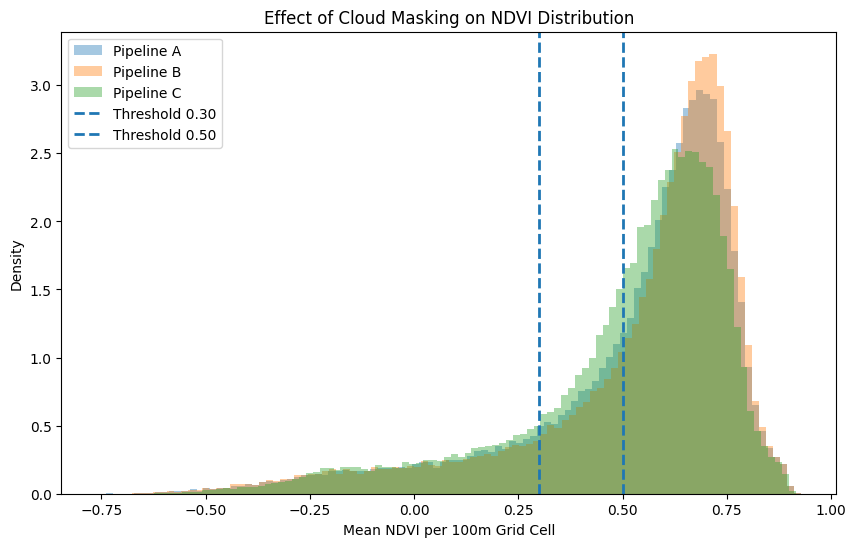

In [ ]:
df = df.copy()

plt.figure(figsize=(10,6))

plt.hist(df["NDVI_A"], bins=100, density=True, alpha=0.4, label="Pipeline A")
plt.hist(df["NDVI_B"], bins=100, density=True, alpha=0.4, label="Pipeline B")
plt.hist(df["NDVI_C"], bins=100, density=True, alpha=0.4, label="Pipeline C")

plt.axvline(0.30, linestyle="--", linewidth=2, label="Threshold 0.30")
plt.axvline(0.50, linestyle="--", linewidth=2, label="Threshold 0.50")

plt.xlabel("Mean NDVI per 100m Grid Cell")
plt.ylabel("Density")
plt.title("Effect of Cloud Masking on NDVI Distribution")
plt.legend()

plt.show()